# Preprocessing et entraînement (Deep Learning - Distillation GPT2)
*(Génération de **programmes sportifs**)*

- **Dataset Kaggle** :  
  [600K+ Fitness Exercise & Workout Program Dataset – Kaggle](https://www.kaggle.com/datasets/adnanelouardi/600k-fitness-exercise-and-workout-program-dataset)

## Imports

In [ ]:
# Bibliothèques principales
import re
from pathlib import Path
import platform
import random
import textwrap
import warnings
import json
from datetime import datetime

# Imports Python / data science classiques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from IPython.display import clear_output
from itables import show

# PyTorch & HuggingFace (version Transformers pour la distillation GPT-2)
import torch
import transformers
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM

## Configuration

### Configuration GPU

In [ ]:
warnings.filterwarnings("ignore")

# Infos système
print("Environnement Windows (PyTorch / Transformers)\n")
print(f"Système      : {platform.system()} {platform.release()}")
print(f"Architecture : {platform.machine()}")

# GPU / CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"\nGPU détecté : {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("\nAucun GPU CUDA détecté — utilisation du CPU (plus lent)")

TrAIn.me — Environnement Windows (PyTorch / Transformers)

Système      : Windows 10
Architecture : AMD64

Aucun GPU CUDA détecté — utilisation du CPU (plus lent)


### Configuration graphiques

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

root = Path.cwd()
themes_root = None

for p in [root, *root.parents]:
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("Ajouté au PYTHONPATH :", themes_root)
print("Contenu de", themes_root, ":", [x.name for x in (themes_root).iterdir()])

# Thème personnalisé du projet (uniquement pour les notebooks)
from themes.theme_train_me import set_trainme_theme

# Appliquer le thème graphique TrAIn.me
set_trainme_theme()

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Le notebook s’exécute depuis son répertoire → on peut repartir du cwd
current_dir = Path.cwd()
project_root = current_dir.parents[3]  # remonte jusqu’à "train.me"

# Thème TrAIn.me (Seaborn/Matplotlib)=
palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
palette_trainme

### Header expérimental

In [ ]:
# Reproductibilité complète
SEED_GLOBAL = 42
random.seed(SEED_GLOBAL)
np.random.seed(SEED_GLOBAL)
torch.manual_seed(SEED_GLOBAL)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_GLOBAL)


OUTPUT_MODEL_NAME = "distillation_gpt2_v11"
 
# Longueur des séquences
MAX_LENGTH = 128 # On garde 128 pour rester CPU-friendly
# Batch & split
BATCH_SIZE = 4 # Plus petit batch → gradients plus stables sur CPU
TRAIN_RATIO = 0.85 # 85% train, 15% validation
TOTAL_SAMPLES = 1596
 
NUM_TRAIN_SAMPLES = int(TOTAL_SAMPLES * TRAIN_RATIO)
NUM_VAL_SAMPLES = TOTAL_SAMPLES - NUM_TRAIN_SAMPLES
 
print(f"Train samples : {NUM_TRAIN_SAMPLES} | Val samples : {NUM_VAL_SAMPLES}")

# Hyperparamètres (version TrAIn.me)
BASELINE_EPOCHS = 6
LR = 3e-5

# distilgpt2 = version compacte (~82M → ~6 couches)
STUDENT_CHECKPOINT = "distilgpt2"
# Tester d'autres modèles
# Checkpoint du Teacher (à remplacer plus tard par ton modèle finetuné TrAIn.me) + voir self-distillation
TEACHER_CHECKPOINT = "gpt2"   # Teacher = GPT-2 Base (~124M)
# TEACHER_CHECKPOINT = "gpt2-medium"   # Teacher = GPT-2 Medium (345M)
# # Self-distillation
# # Détection du chemin du notebook
# notebook_dir = Path().resolve()
# # Racine du projet : remonter 3 dossiers (src/notebooks/... → trAIn.me/)
# project_root = notebook_dir.parent.parent.parent
# TEACHER_CHECKPOINT = str(project_root / "models" / "distillation_gpt2_v6")
# teacher_tokenizer = AutoTokenizer.from_pretrained(TEACHER_CHECKPOINT)
# teacher_model = AutoModelForCausalLM.from_pretrained(TEACHER_CHECKPOINT)
# TEACHER_CHECKPOINT = "gpt2-large"   # À garder pour plus tard --> machine plus musclée ou du cloud.
# microsoft/DialoGPT-medium --> un Student plus “dialogue coach” que “fiche programme”

DISTILL_EPOCHS = 5
TEMPERATURE = 1.0
ALPHA = 0.5  # poids de la hard loss (labels réels)

Train samples : 1356 | Val samples : 240


### Affichage des versions d'imports

In [106]:
print("\nVersions utilisées :")
print(f"  - torch        : {torch.__version__}")
print(f"  - transformers : {transformers.__version__}")
print("  - datasets     : installé (HuggingFace Datasets)")
print("\nEnvironnement configuré — prêt pour la distillation GPT-2 spécialisée TrAIn.me !")


Versions utilisées :
  - torch        : 2.9.1+cpu
  - transformers : 4.57.3
  - datasets     : installé (HuggingFace Datasets)

Environnement configuré — prêt pour la distillation GPT-2 spécialisée TrAIn.me !


## Chargement du modèle Teacher

In [ ]:
# Tokenizer
teacher_tokenizer = AutoTokenizer.from_pretrained(TEACHER_CHECKPOINT)

# GPT-2 n’a pas de pad token → on utilise `eos` comme pad
if teacher_tokenizer.pad_token is None:
    teacher_tokenizer.pad_token = teacher_tokenizer.eos_token

# Modèle Teacher
teacher_model = AutoModelForCausalLM.from_pretrained(TEACHER_CHECKPOINT)
teacher_model = teacher_model.to(device)

# Nombre total de paramètres
teacher_params = sum(p.numel() for p in teacher_model.parameters())

print("Modèle Teacher chargé avec succès !\n")
print("Informations sur le Teacher (GPT-2 Base / pré-finetuning TrAIn.me) :")
print(f"  - Checkpoint      : {TEACHER_CHECKPOINT}")
print(f"  - Paramètres      : {teacher_params:,}  (~{teacher_params/1e6:.1f}M)")
print(f"  - Taille mémoire  : {teacher_params * 4 / (1024**2):.1f} MB")
print(f"  - Vocabulaire     : {len(teacher_tokenizer)} tokens")

Modèle Teacher chargé avec succès !

Informations sur le Teacher (GPT-2 Base / pré-finetuning TrAIn.me) :
  - Checkpoint      : gpt2
  - Paramètres      : 124,439,808  (~124.4M)
  - Taille mémoire  : 474.7 MB
  - Vocabulaire     : 50257 tokens

Le Teacher est maintenant prêt à guider le Student dans la distillation TrAIn.me.


## Chargement du Modèle Student (GPT-2 Compact)

In [ ]:
# Tokenizer du Student (même vocabulaire que GPT-2, parfait pour la distillation)
student_tokenizer = AutoTokenizer.from_pretrained(STUDENT_CHECKPOINT)

# Même règle que pour le Teacher : GPT-2 n’a pas de pad_token → on utilise eos
if student_tokenizer.pad_token is None:
    student_tokenizer.pad_token = student_tokenizer.eos_token

# Chargement du modèle Student compact
student_model = AutoModelForCausalLM.from_pretrained(STUDENT_CHECKPOINT)
student_model = student_model.to(device)

# Nombre total de paramètres
student_params = sum(p.numel() for p in student_model.parameters())

print("Modèle Student chargé avec succès !\n")
print("Informations sur le Student (GPT-2 Compact) :")
print(f"  - Checkpoint      : {STUDENT_CHECKPOINT}")
print(f"  - Paramètres      : {student_params:,}  (~{student_params/1e6:.1f}M)")
print(f"  - Taille mémoire  : {student_params * 4 / (1024**2):.1f} MB")
print(f"  - Vocabulaire     : {len(student_tokenizer)} tokens")

# Comparaison Teacher vs Student
compression_ratio = teacher_params / student_params
print(f"\nComparaison Teacher vs Student :")
print(f"  - Ratio de compression : {compression_ratio:.2f}x plus petit")
print(f"  - Réduction mémoire    : {100 * (1 - 1/compression_ratio):.1f}%")

Chargement du modèle Student (GPT-2 Compact pour TrAIn.me)...

Modèle Student chargé avec succès !

Informations sur le Student (GPT-2 Compact) :
  - Checkpoint      : distilgpt2
  - Paramètres      : 81,912,576  (~81.9M)
  - Taille mémoire  : 312.5 MB
  - Vocabulaire     : 50257 tokens

Comparaison Teacher vs Student :
  - Ratio de compression : 1.52x plus petit
  - Réduction mémoire    : 34.2%

Le Student est compact – idéal pour la distillation et le déploiement dans TrAIn.me.


## Chargement et Préparation du Corpus TrAIn.me

In [ ]:
# Téléchargement automatique du dataset Kaggle
path = kagglehub.dataset_download(
    "adnanelouardi/600k-fitness-exercise-and-workout-program-dataset"
)

print("Dataset téléchargé avec succès !")
print("Chemin local :", path, "\n")

# Conversion du chemin KaggleHub → Path
dataset_dir = Path(path)

# Fichier CSV principal (structure confirmée dans le dataset Kaggle)
csv_path = dataset_dir / "program_summary.csv"

print(f"Lecture du fichier : {csv_path.name}\n")

# Chargement du corpus fusionné
df_sum = pd.read_csv(csv_path)

print("Corpus chargé avec succès !\n")
print("Aperçu du corpus :")
print(df_sum.head())

print("\nInformations générales :")
print(f"  - Nombre total d’entrées : {len(df_sum)}")
print(f"  - Colonnes disponibles    : {list(df_sum.columns)}")

print("\nConfiguration TrAIn.me :")
print(f"  - Longueur max     : {MAX_LENGTH} tokens")
print(f"  - Train samples    : {NUM_TRAIN_SAMPLES}")
print(f"  - Val samples      : {NUM_VAL_SAMPLES}")
print(f"  - Batch size       : {BATCH_SIZE}")

print("\nCorpus prêt pour la construction du dataset HuggingFace et la tokenisation.")

### Suppression des colonnes inutiles

In [ ]:
cols_to_drop = [
    "program_length",
    "time_per_workout",
    "total_exercises",
    "created",
    "last_edit",
]

# On supprime seulement celles qui existent (pour éviter les KeyError)
df_sum = df_sum.drop(columns=[c for c in cols_to_drop if c in df_sum.columns], errors="ignore")

print(list(df_sum.columns))
df = df_sum

### Valeurs manquantes

In [ ]:
print("\nVérification des valeurs manquantes dans df :\n")

# Nombre de valeurs manquantes par colonne
missing_counts = df.isna().sum()

print("Nombre de valeurs manquantes par colonne :")
print(missing_counts)
print("\n")

# Pourcentage de valeurs manquantes par colonne
missing_pct = (df.isna().mean() * 100).round(2)

print("Pourcentage de valeurs manquantes :")
print(missing_pct)
print("\n")

# Résumé clair
print("Synthèse :")
for col in df.columns:
    print(
        f" - {col}: {missing_counts[col]} manquants "
        f"({missing_pct[col]}%)"
    )


🔍 Vérification des valeurs manquantes dans df :

Nombre de valeurs manquantes par colonne :
title             0
description    1600
level           617
goal              0
equipment        52
dtype: int64


Pourcentage de valeurs manquantes :
title           0.00
description    44.74
level          17.25
goal            0.00
equipment       1.45
dtype: float64


📌 Synthèse :
 - title: 0 manquants (0.0%)
 - description: 1600 manquants (44.74%)
 - level: 617 manquants (17.25%)
 - goal: 0 manquants (0.0%)
 - equipment: 52 manquants (1.45%)


## Suppression des valeurs manquantes

In [ ]:
# Comptage avant suppression
before = len(df)

# Suppression des NaN + descriptions vides ou uniquement espaces
df = df.dropna(subset=["description"])
df = df[df["description"].astype(str).str.strip() != ""]

# Comptage après suppression
after = len(df)

print(f"Lignes avant nettoyage : {before}")
print(f"Lignes après nettoyage : {after}")
print(f"> {before - after} lignes supprimées (description manquante)")


🧹 Suppression des lignes avec description manquante...

Lignes avant nettoyage : 3576
Lignes après nettoyage : 1976
➡️ 1600 lignes supprimées (description manquante)


### Data cleaning des données non-structuées
#### Filtrage des descriptions : détection des textes peu informatifs


In [ ]:
GENERIC_PATTERNS = [
    r"^n/?a$",
    r"^no description$",
    r"^none$",
    r"^-$",
    r"^program description$",
    r"^program$",
]

def is_low_info(text: str) -> bool:
    """
    Détecte les descriptions peu informatives :
    - très courtes
    - bourrées de caractères non alphabétiques
    - répétitives ou génériques
    """
    if not isinstance(text, str):
        return True

    txt = text.strip().lower()

    # Vide après strip
    if txt == "":
        return True

    # Expressions génériques connues
    for pat in GENERIC_PATTERNS:
        if re.fullmatch(pat, txt):
            return True

    # Compter mots / caractères
    words = txt.split()
    n_words = len(words)
    n_chars = len(txt)

    # Très court : on marque comme faible info
    if n_words < 5 or n_chars < 20:
        return True

    # Proportion de lettres vs tout le reste
    letters = sum(ch.isalpha() for ch in txt)
    ratio_letters = letters / max(1, n_chars)
    if ratio_letters < 0.5:
        # Trop de chiffres/symboles → souvent du bruit
        return True

    # Répétition : peu de mots uniques par rapport au total
    unique_words = len(set(words))
    if n_words >= 10 and unique_words / n_words < 0.3:
        return True

    return False


def clean_program_descriptions(df: pd.DataFrame,
                               desc_col: str = "description") -> pd.DataFrame:
    """
    Applique un filtre qualité sur les descriptions de programmes.

    - Supprime les lignes avec description vide / NaN
    - Ajoute des métriques de longueur
    - Marque les descriptions peu informatives
    - Retourne un df filtré + les colonnes de diagnostic
    """
    df = df.copy()

    # Forcer string, gérer NaN
    df[desc_col] = df[desc_col].astype(str).str.strip()
    df["desc_is_nan"] = df[desc_col].isna() | (df[desc_col] == "")

    # Longueurs brutes
    df["desc_n_chars"] = df[desc_col].str.len()
    df["desc_n_words"] = df[desc_col].apply(lambda x: len(x.split()))

    # Flag qualité (low info)
    df["desc_low_info"] = df[desc_col].apply(is_low_info)

    # Décision finale : à garder si non-NaN et pas low_info
    df["keep_for_corpus"] = (~df["desc_is_nan"]) & (~df["desc_low_info"])

    print("\nFiltre qualité descriptions")
    print(f"Total lignes       : {len(df)}")
    print(f"Descriptions gardées : {df['keep_for_corpus'].sum()}")
    print(f"Descriptions rejetées : {(~df['keep_for_corpus']).sum()}")
    print("Raisons principales (approx) :")
    print(f"- NaN / vide / ultra-court : "
          f"{(df['desc_n_words'] < 5).sum()} lignes")
    print(f"- Low info (pattern / bruit / répétition) : "
          f"{df['desc_low_info'].sum()} lignes")

    # Retourner uniquement les lignes retenues, mais AVEC les métriques utiles
    return df[df["keep_for_corpus"]].reset_index(drop=True)

df = clean_program_descriptions(df, desc_col="description")
print(df.head())


===== Filtre qualité descriptions =====
Total lignes       : 1976
Descriptions gardées : 1976
Descriptions rejetées : 0
----------------------------------------
Raisons principales (approx) :
- NaN / vide / ultra-court : 0 lignes
- Low info (pattern / bruit / répétition) : 0 lignes
                          title  \
0        Partner plank band row   
1  Banded crunch isometric hold   
2         FYR Banded Plank Jack   
3                 Banded crunch   
4                        Crunch   

                                         description         level  \
0  The partner plank band row is an abdominal exe...  Intermediate   
1  The banded crunch isometric hold is an exercis...  Intermediate   
2  The banded plank jack is a variation on the pl...  Intermediate   
3  The banded crunch is an exercise targeting the...  Intermediate   
4  The crunch is a popular core exercise targetin...  Intermediate   

         goal equipment  desc_is_nan  desc_n_chars  desc_n_words  \
0  Abdominals   

#### Nettoyage avancé du texte : normalisation et reconstruction des phrases

In [ ]:
BULLET_CHARS = "•●▪◦*-"

def normalize_style_basic(text: str) -> str:
    if not isinstance(text, str):
        return ""

    txt = text.replace("\r\n", "\n").replace("\r", "\n")

    # Échapper les caractères spéciaux pour la classe de caractères
    bullet_escaped = re.escape(BULLET_CHARS)

    # Enlever les puces en début de ligne
    #    Ex : "• Day 1: ..." → "Day 1: ..."
    txt = re.sub(rf"^[{bullet_escaped}\s]+\s*", "", txt, flags=re.MULTILINE)

    # Remplacer les puces isolées par des espaces
    txt = re.sub(rf"[{bullet_escaped}]", " ", txt)

    # Normaliser la ponctuation
    txt = re.sub(r"\s*([.,!?;:])\s*", r"\1 ", txt)

    # Coller les unités / %
    txt = re.sub(r"\s+(%|kg|lbs|reps?|sets?)", r" \1", txt)

    # Réduire les espaces multiples
    txt = re.sub(r"\s+", " ", txt)

    # Nettoyer les espaces avant ponctuation finale
    txt = re.sub(r"\s+([.,!?])", r"\1", txt)

    return txt.strip()

# Gérer les répétitions et phrases cassées
def clean_sentences(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # Split en pseudo-phrases
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())

    cleaned = []
    seen = set()

    for s in sentences:
        s = s.strip()
        if not s:
            continue

        # Virer les phrases ultra-courtes (cassées ou sans info)
        #    ex : "and continue", "get the results"
        word_count = len(s.split())
        if word_count < 4:
            continue

        # Éviter les répétitions exactes
        key = s.lower()
        if key in seen:
            continue
        seen.add(key)

        cleaned.append(s)

    # Recolle proprement
    text_cleaned = " ".join(cleaned).strip()

    # Si ça ne finit pas par une ponctuation, ajouter un point
    if text_cleaned and text_cleaned[-1] not in ".!?":
        text_cleaned += "."

    return text_cleaned

### Ajout de la colonne "clean_text"

In [ ]:
print("Construction du corpus reconstruit (clean_text)...\n")

def construire_clean_text(row):
    """
    Construit un texte propre et structuré pour l'entraînement GPT-2
    à partir des colonnes du dataset Kaggle :
    - title
    - level
    - goal
    - description
    """

    title = str(row.get("title", "")).strip()
    level = str(row.get("level", "")).strip()
    goal = str(row.get("goal", "")).strip()
    description = str(row.get("description", "")).strip()

    # Nettoyage minimal de la description
    description = description.replace("\n", " ").replace("  ", " ").strip()

    texte = (
        f"Generate a workout program at [{level}] level. "
        f"The exercise to generate is titled [{title}], "
        f"it targets the [{goal}].\n\n"
        f"Program Description:\n"
        f"{description}"
    )

    return texte

# Application au DataFrame
df["clean_text"] = df.apply(construire_clean_text, axis=1)

print("Colonne 'clean_text' créée.")
print("Aperçu :")
show(df[["title", "level", "goal", "clean_text"]].head())


Construction du corpus reconstruit (clean_text)...

✅ Colonne 'clean_text' créée.
Aperçu :


,title,level,goal,clean_text
0,Partner plank band row,Intermediate,Abdominals,Generate a workout program at [Intermediate] l...
1,Banded crunch isometric hold,Intermediate,Abdominals,Generate a workout program at [Intermediate] l...
2,FYR Banded Plank Jack,Intermediate,Abdominals,Generate a workout program at [Intermediate] l...
3,Banded crunch,Intermediate,Abdominals,Generate a workout program at [Intermediate] l...
4,Crunch,Intermediate,Abdominals,Generate a workout program at [Intermediate] l...


### Statistiques et distribution



Analyse des longueurs et distribution du corpus TrAIn.me (clean_text)



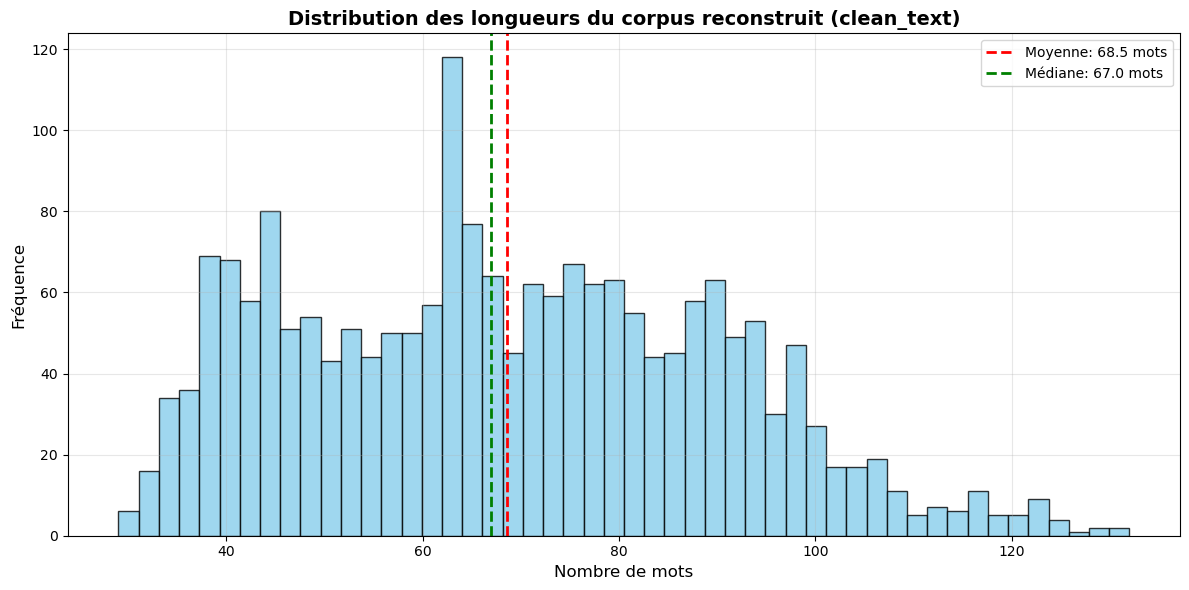


Statistiques détaillées :

Métrique                       Valeur              
-------------------------------------------------------
Nombre total d exemples        1976                
Longueur moyenne (mots)        68.5                
Longueur médiane (mots)        67.0                
Min / Max (mots)               29 / 132                 


In [ ]:
# Vérifier que clean_text existe
if "clean_text" not in df.columns:
    raise ValueError("La colonne 'clean_text' n'existe pas encore. "
                     "Vous devez d'abord construire le corpus reconstruit.")

# Longueurs des textes du corpus
text_lengths = df["clean_text"].astype(str).apply(lambda x: len(x.split()))

# Visualisation
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.hist(text_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
ax.axvline(np.mean(text_lengths), color='red', linestyle='--', linewidth=2,
           label=f"Moyenne: {np.mean(text_lengths):.1f} mots")
ax.axvline(np.median(text_lengths), color='green', linestyle='--', linewidth=2,
           label=f"Médiane: {np.median(text_lengths):.1f} mots")

ax.set_xlabel("Nombre de mots", fontsize=12)
ax.set_ylabel("Fréquence", fontsize=12)
ax.set_title("Distribution des longueurs du corpus reconstruit (clean_text)", fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Statistiques
print("\nStatistiques détaillées :\n")
print(f"{'Métrique':<30} {'Valeur':<20}")
print(f"{'Nombre total d exemples':<30} {len(text_lengths):<20}")
print(f"{'Longueur moyenne (mots)':<30} {np.mean(text_lengths):<20.1f}")
print(f"{'Longueur médiane (mots)':<30} {np.median(text_lengths):<20.1f}")
print(f"{'Min / Max (mots)':<30} {text_lengths.min()} / {text_lengths.max():<20}")

### Préparation du Corpus TrAIn.me pour l’Entraînement et la Distillation


#### Fonction de préparation du corpus TrAIn.me

In [ ]:
def preparer_corpus_trainme(df, num_samples):
    """
    Prépare le corpus final pour GPT-2 en utilisant la colonne clean_text,
    déjà structurée au bon format.

    Args:
        df : DataFrame contenant `clean_text`
        num_samples : nombre maximum d'échantillons à utiliser

    Retour :
        Liste de textes prêts pour entraînement.
    """

    if "clean_text" not in df.columns:
        raise KeyError(
            "La colonne 'clean_text' est absente. "
            "Vous devez d'abord construire le corpus reconstruit."
        )

    df_clean = df.dropna(subset=["clean_text"]).head(num_samples)

    # On récupère directement la colonne propre
    textes = df_clean["clean_text"].astype(str).tolist()

    return textes

In [121]:
def normalize_goal(raw):
    txt = str(raw).strip()
    # Si c’est une liste encodée en string → on ne garde que le premier élément
    if txt.startswith("[") and txt.endswith("]"):
        # cas simple : ['Bodybuilding', 'Powerlifting']
        txt = txt.strip("[]")
        # on sépare sur virgule et on prend le premier élément propre
        txt = txt.split(",")[0]
    # Nettoyage des quotes et espaces
    return txt.strip(" '\"")

def normalize_level(raw):
    txt = str(raw).strip()
    if txt.startswith("[") and txt.endswith("]"):
        txt = txt.strip("[]").split(",")[0]
    return txt.strip(" '\"")

In [ ]:
def build_goal_sentence(goal: str) -> str:
    """
    Génère une phrase anatomique basée sur la cible de l'exercice.
    Si plusieurs groupes sont listés, on génère une phrase générique mais utile.
    """
    g = goal.strip()

    # Cas simple : un seul muscle
    if "," not in g and " " not in g:
        return f"This exercise mainly targets the {g}, helping you develop strength and control in this area."

    # Cas où plusieurs groupes --> phrase plus large
    return (
        f"This exercise primarily engages the {g}, improving stability, functional strength, "
        f"and overall performance related to these muscle groups."
    )

In [ ]:
def build_trainme_prompt(row):
    level = normalize_level(row["level"])
    goal  = normalize_goal(row["goal"]) # ex: "Quadriceps" ou "Obliques, Core"
    title = str(row["title"]).strip() # ex: "Barbell Hack Squat"

    desc_clean = clean_sentences(
        normalize_style_basic(str(row["description"]))
    )

    # Version lisible pour affichage
    goal_display = goal.replace(",", " and")

    return (
        f"Generate a workout program at [{level}] level.\n"
        f"The exercise to generate is a gym exercise titled [{title}]. "
        f"It is a strength training movement performed in the gym, not a car part.\n"
        f"The main target muscle group is [{goal}], and ALL exercises "
        f"must primarily work the [{goal}].\n\n"
        f"Program Description (short): {desc_clean}\n\n"
        f"Now write the program using EXACTLY this structure:\n\n"
        f"1) Title: {title}\n"
        f"2) Target muscles: {goal_display}\n"
        f"3) Main benefits: explain how this program improves the {goal_display}.\n"
        f"4) Cues: give 3–5 concrete technical cues focused on the {goal_display} "
        f"(breathing, bracing, joint alignment).\n"
        f"5) Workout plan:\n"
        f"   - List 3–5 exercises.\n"
        f"   - For EACH exercise, write: name, sets x reps, and 1 sentence explaining "
        f"how it trains the {goal_display}.\n"
        f"6) Finisher: optional core or isolation work still targeting the {goal_display}.\n"
        f"Do not talk about cars, vehicles or windshields. Focus only on gym exercises.\n"
    )

#### Train / Validation split

In [ ]:
# On s'assure que clean_text existe et qu'il n'est pas vide
if "clean_text" not in df.columns:
    raise KeyError(
        "La colonne 'clean_text' est absente. "
        "Vous devez d'abord construire le corpus reconstruit."
    )

df_clean = df.dropna(subset=["clean_text"]).copy()

# Mélange reproductible puis split train / val
df_clean = df_clean.sample(frac=1.0, random_state=SEED_GLOBAL).reset_index(drop=True)

df_train = df_clean.head(NUM_TRAIN_SAMPLES).copy()
train_texts = [build_trainme_prompt(row) for _, row in df_train.iterrows()]

df_val = df_clean.sample(NUM_VAL_SAMPLES, random_state=SEED_GLOBAL)
val_texts = [build_trainme_prompt(row) for _, row in df_val.iterrows()]

print("Corpus préparé !")
print(f"  - Train : {len(train_texts)} textes")
print(f"  - Val   : {len(val_texts)} textes")

Préparation du corpus TrAIn.me à partir de 'clean_text'...

Corpus préparé !
  - Train : 1356 textes
  - Val   : 240 textes


#### Tokenisation (Teacher Tokenizer --> vocabulaire GPT-2)

In [ ]:
def tokenize_function(batch):
    return teacher_tokenizer(
        batch,
        padding="longest", # plus adapté pour GPT-2
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

# Encodage
train_encodings = tokenize_function(train_texts)
val_encodings   = tokenize_function(val_texts)

#### Dataset PyTorch

In [126]:
class TrainmeDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}

    def __len__(self):
        return self.encodings["input_ids"].shape[0]


train_dataset = TrainmeDataset(train_encodings)
val_dataset   = TrainmeDataset(val_encodings)

print("\nDatasets PyTorch créés !")
print(f"  - Train dataset : {len(train_dataset)} items")
print(f"  - Val dataset   : {len(val_dataset)} items")


Datasets PyTorch créés !
  - Train dataset : 1356 items
  - Val dataset   : 240 items


#### DataLoader PyTorch

In [127]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

print("\nDataLoader PyTorch prêts pour l'entraînement !")


DataLoader PyTorch prêts pour l'entraînement !


## Baseline : Entraînement Direct du Student (sans Distillation)


In [ ]:
baseline_student = AutoModelForCausalLM.from_pretrained(STUDENT_CHECKPOINT)
baseline_student = baseline_student.to(device)
baseline_student.train()

# Optimiseur + Loss (CrossEntropy classique)
optimizer = torch.optim.AdamW(baseline_student.parameters(), lr=LR)
loss_fct = torch.nn.CrossEntropyLoss(
    ignore_index=teacher_tokenizer.pad_token_id
)

# Callbacks simples pour suivre la training/val loss
class BaselineHistory:
    def __init__(self):
        self.history_loss = []
        self.history_val_loss = []

callback_baseline = BaselineHistory()

print("Student BASELINE initialisé !")
print("\nEntraînement du Student (sans distillation...\n")

for epoch in range(BASELINE_EPOCHS):

    # TRAIN
    baseline_student.train()
    train_losses = []

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        labels = input_ids.clone()

        optimizer.zero_grad()

        outputs = baseline_student(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits   # (batch, seq_len, vocab_size)

        # Décalage causal LM : prédire le token suivant
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1)
        )

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    avg_train_loss = float(np.mean(train_losses))
    callback_baseline.history_loss.append(avg_train_loss)


    # VALIDATION
    baseline_student.eval()
    val_losses = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = input_ids.clone()

            outputs = baseline_student(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits

            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()

            val_loss = loss_fct(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1)
            )
            val_losses.append(val_loss.item())

    avg_val_loss = float(np.mean(val_losses))
    callback_baseline.history_val_loss.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{BASELINE_EPOCHS} - "
        f"Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}"
    )

print("\nEntraînement BASELINE terminé !")
print(f"   Final Val Loss: {callback_baseline.history_val_loss[-1]:.4f}")

Création du Student BASELINE (entraînement direct, sans distillation)...

Student BASELINE initialisé !

Entraînement du Student (sans distillation, corpus TrAIn.me)...

Epoch 1/10 - Loss: 1.3831 - Val Loss: 0.9393
Epoch 2/10 - Loss: 0.9617 - Val Loss: 0.8010
Epoch 3/10 - Loss: 0.8417 - Val Loss: 0.7117
Epoch 4/10 - Loss: 0.7557 - Val Loss: 0.6419
Epoch 5/10 - Loss: 0.6863 - Val Loss: 0.5804
Epoch 6/10 - Loss: 0.6295 - Val Loss: 0.5383
Epoch 7/10 - Loss: 0.5802 - Val Loss: 0.4968
Epoch 8/10 - Loss: 0.5359 - Val Loss: 0.4659
Epoch 9/10 - Loss: 0.4975 - Val Loss: 0.4350
Epoch 10/10 - Loss: 0.4643 - Val Loss: 0.4102

Entraînement BASELINE terminé !
   Final Val Loss: 0.4102


## Distillation : Entraîner le Student avec le Teacher


In [ ]:
# Student utilisé pour la distillation : on réutilise le même checkpoint global
DISTILL_STUDENT_CHECKPOINT = STUDENT_CHECKPOINT 

# Tokenizer du Student distillé
distilled_student_tokenizer = AutoTokenizer.from_pretrained(DISTILL_STUDENT_CHECKPOINT)

# GPT-2 n’a pas de pad token → on utilise le token EOS
if distilled_student_tokenizer.pad_token is None:
    distilled_student_tokenizer.pad_token = distilled_student_tokenizer.eos_token

# Modèle Student compact pour distillation
distilled_student = AutoModelForCausalLM.from_pretrained(DISTILL_STUDENT_CHECKPOINT)
distilled_student = distilled_student.to(device)
distilled_student.train()

# Nombre total de paramètres
distilled_student_params = sum(p.numel() for p in distilled_student.parameters())

print("Student pour distillation initialisé !\n")
print("Informations sur le Student (Compact pour distillation) :")
print(f"  - Checkpoint      : {DISTILL_STUDENT_CHECKPOINT}")
print(f"  - Paramètres      : {distilled_student_params:,}  (~{distilled_student_params/1e6:.1f}M)")
print(f"  - Taille mémoire  : {distilled_student_params * 4 / (1024**2):.1f} MB")
print(f"  - Vocabulaire     : {len(distilled_student_tokenizer)} tokens")

# Ratio de compression par rapport au Teacher
compression_ratio = teacher_params / distilled_student_params
print(f"\nCompression Teacher → Student : {compression_ratio:.2f}x")

Création du Student pour la DISTILLATION (Transformers / TrAIn.me)...

Student pour distillation initialisé !

Informations sur le Student (Compact pour distillation) :
  - Checkpoint      : distilgpt2
  - Paramètres      : 81,912,576  (~81.9M)
  - Taille mémoire  : 312.5 MB
  - Vocabulaire     : 50257 tokens

Compression Teacher → Student : 1.52x

Le Student compact est prêt pour l’étape de distillation TrAIn.me !


### Mise en place de la distillation (Teacher → Student)


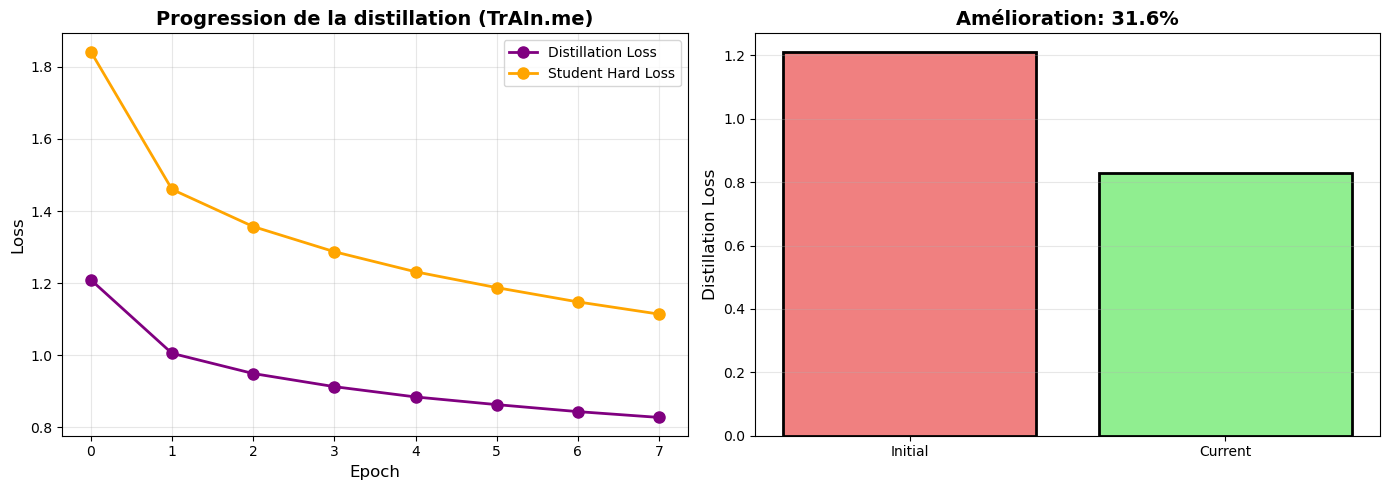

Epoch 8/8
Distillation Loss: 0.8275 | Student Loss: 1.1141

Distillation terminée !
Le Student compact a appris du Teacher sur le corpus sportif TrAIn.me !


In [ ]:
# Loss pour les labels "durs"
ce_loss_fct = torch.nn.CrossEntropyLoss(
    ignore_index=teacher_tokenizer.pad_token_id
)

# KLDiv pour les "soft labels" (distribution Teacher vs Student)
kl_loss_fct = torch.nn.KLDivLoss(reduction="batchmean")

# Optimiseur du Student distillé (on utilise la LR globale)
distill_optimizer = torch.optim.AdamW(distilled_student.parameters(), lr=LR)

# Callback façon Keras, mais en PyTorch
class DistillationCallback:
    def __init__(self, total_epochs):
        self.total_epochs = total_epochs
        self.history_distill_loss = []
        self.history_student_loss = []

    def on_epoch_end(self, epoch, distill_loss, student_loss):
        self.history_distill_loss.append(distill_loss)
        self.history_student_loss.append(student_loss)

        clear_output(wait=True)

        plt.figure(figsize=(14, 5))

        # Graphe 1 : progression des losses
        plt.subplot(1, 2, 1)
        plt.plot(
            self.history_distill_loss,
            "o-",
            color="purple",
            linewidth=2,
            markersize=8,
            label="Distillation Loss",
        )
        plt.plot(
            self.history_student_loss,
            "o-",
            color="orange",
            linewidth=2,
            markersize=8,
            label="Student Hard Loss",
        )
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("Loss", fontsize=12)
        plt.title("Progression de la distillation (TrAIn.me)", fontsize=14, fontweight="bold")
        plt.legend()
        plt.grid(alpha=0.3)

        # Graphe 2 : amélioration distillation loss
        plt.subplot(1, 2, 2)
        if len(self.history_distill_loss) > 1:
            initial = self.history_distill_loss[0]
            current = self.history_distill_loss[-1]
            improvement = ((initial - current) / initial) * 100

            plt.bar(
                ["Initial", "Current"],
                [initial, current],
                color=["lightcoral", "lightgreen"],
                edgecolor="black",
                linewidth=2,
            )
            plt.ylabel("Distillation Loss", fontsize=12)
            plt.title(f"Amélioration: {improvement:.1f}%", fontsize=14, fontweight="bold")
            plt.grid(alpha=0.3, axis="y")
        else:
            plt.bar(
                ["Initial"],
                [self.history_distill_loss[0]],
                color=["lightcoral"],
                edgecolor="black",
                linewidth=2,
            )
            plt.ylabel("Distillation Loss", fontsize=12)
            plt.title("Amélioration: N/A", fontsize=14, fontweight="bold")
            plt.grid(alpha=0.3, axis="y")

        plt.tight_layout()
        plt.show()

        print(f"Epoch {epoch+1}/{self.total_epochs}")
        print(
            f"Distillation Loss: {distill_loss:.4f} | "
            f"Student Loss: {student_loss:.4f}"
        )

# On garde le même pattern que dans le TP d’origine
callback_distill = DistillationCallback(total_epochs=DISTILL_EPOCHS)

print("Distillation en cours sur le corpus TrAIn.me...\n")

for epoch in range(DISTILL_EPOCHS):
    distilled_student.train()
    teacher_model.eval()

    epoch_distill_losses = []
    epoch_student_losses = []

    # TRAIN
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = input_ids.clone()

        # Forward Teacher (no grad)
        with torch.no_grad():
            teacher_outputs = teacher_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            teacher_logits = teacher_outputs.logits

        # Forward Student
        student_outputs = distilled_student(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        student_logits = student_outputs.logits

        # Décalage pour LM causal (prédire le token suivant)
        t_logits = teacher_logits[:, :-1, :].contiguous()
        s_logits = student_logits[:, :-1, :].contiguous()
        s_labels = labels[:, 1:].contiguous()

        # Hard loss (Student vs tokens réels)
        hard_loss = ce_loss_fct(
            s_logits.view(-1, s_logits.size(-1)),
            s_labels.view(-1),
        )

        # Soft loss (Teacher → Student, avec température)
        teacher_soft = torch.softmax(t_logits / TEMPERATURE, dim=-1)
        student_log_soft = torch.log_softmax(s_logits / TEMPERATURE, dim=-1)

        soft_loss = kl_loss_fct(
            student_log_soft.view(-1, s_logits.size(-1)),
            teacher_soft.view(-1, t_logits.size(-1)),
        )

        # Loss totale (distillation)
        distill_loss = ALPHA * hard_loss + (1 - ALPHA) * (TEMPERATURE**2) * soft_loss

        # Backprop
        distill_optimizer.zero_grad()
        distill_loss.backward()
        distill_optimizer.step()

        epoch_distill_losses.append(distill_loss.item())
        epoch_student_losses.append(hard_loss.item())

    avg_distill_loss = float(np.mean(epoch_distill_losses))
    avg_student_loss = float(np.mean(epoch_student_losses))

    # Callback "fin d'epoch"
    callback_distill.on_epoch_end(
        epoch,
        avg_distill_loss,
        avg_student_loss,
    )

print("\nDistillation terminée !")

## Comparaison


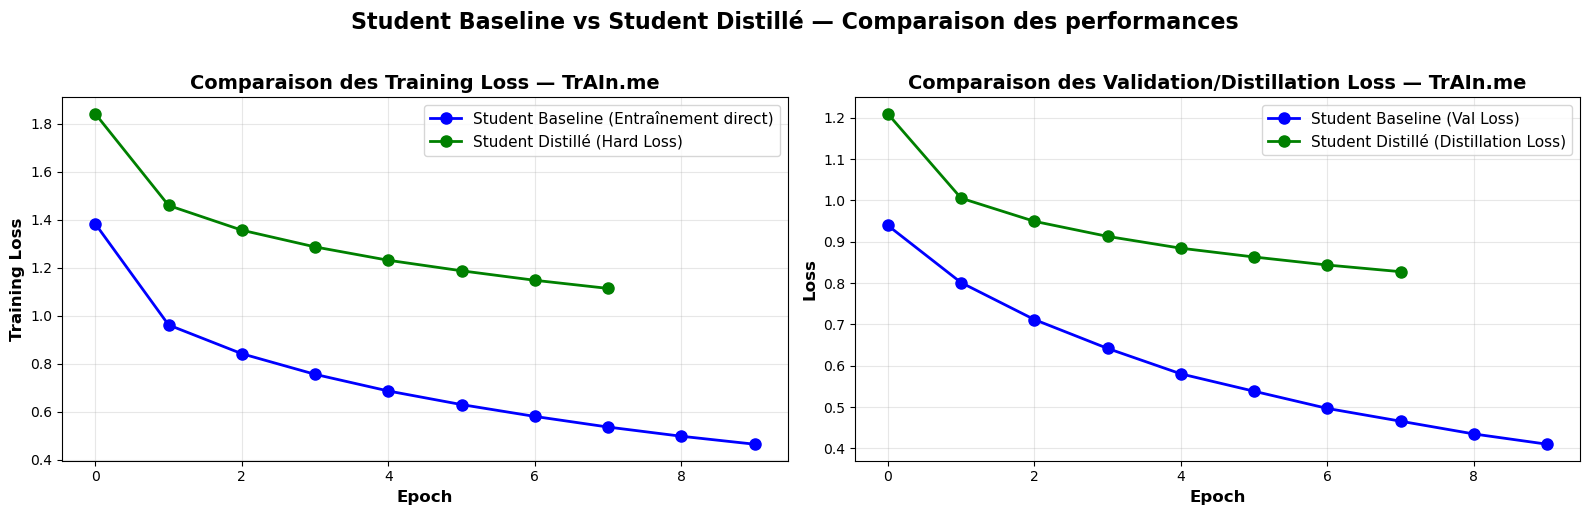

In [ ]:
# Graphiques de comparaison (Baseline vs Distillation)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# TRAINING LOSS
axes[0].plot(
    callback_baseline.history_loss,
    'o-',
    color='blue',
    linewidth=2,
    markersize=8,
    label='Student Baseline (Entraînement direct)'
)

axes[0].plot(
    callback_distill.history_student_loss,
    'o-',
    color='green',
    linewidth=2,
    markersize=8,
    label='Student Distillé (Hard Loss)'
)

axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Training Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Comparaison des Training Loss — TrAIn.me', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)


# VALIDATION / DISTILLATION LOSS
axes[1].plot(
    callback_baseline.history_val_loss,
    'o-',
    color='blue',
    linewidth=2,
    markersize=8,
    label='Student Baseline (Val Loss)'
)

axes[1].plot(
    callback_distill.history_distill_loss,
    'o-',
    color='green',
    linewidth=2,
    markersize=8,
    label='Student Distillé (Distillation Loss)'
)

axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Comparaison des Validation/Distillation Loss — TrAIn.me', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)


plt.suptitle(
    'Student Baseline vs Student Distillé — Comparaison des performances',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

### Synthèse Finale des Performances et de la Compression


In [ ]:
# Comptage des paramètres (PyTorch)
teacher_params_final = sum(p.numel() for p in teacher_model.parameters())
baseline_params_final = sum(p.numel() for p in baseline_student.parameters())
distilled_params_final = sum(p.numel() for p in distilled_student.parameters())

print(f"\n{'Modèle':<35} {'Paramètres':<20} {'Taille (MB)':<15} {'Final Loss':<15}")
print("-"*90)

# Approximation mémoire (float32 = 4 octets)
teacher_size = teacher_params_final * 4 / (1024**2)
baseline_size = baseline_params_final * 4 / (1024**2)
distilled_size = distilled_params_final * 4 / (1024**2)

print(f"{'Teacher (GPT-2 Base)':<35} {teacher_params_final:>19,} {teacher_size:>14.1f} {'N/A':>14}")
print(f"{'Student Baseline (Direct)':<35} {baseline_params_final:>19,} {baseline_size:>14.1f} {callback_baseline.history_val_loss[-1]:>14.4f}")
print(f"{'Student Distillé':<35} {distilled_params_final:>19,} {distilled_size:>14.1f} {callback_distill.history_distill_loss[-1]:>14.4f}")

# Calculs synthétiques
improvement = (
    (callback_baseline.history_val_loss[-1] - callback_distill.history_distill_loss[-1])
    / callback_baseline.history_val_loss[-1]
) * 100

compression = teacher_params_final / distilled_params_final

print(f"\nRÉSULTATS FINAUX :")
print(f"  Amélioration de la loss (Baseline → Distillé) : {improvement:.1f}%")
print(f"  Ratio de compression Teacher → Student         : {compression:.2f}x")
print(f"  Gain mémoire total                             : {(teacher_size - distilled_size):.1f} MB")
print(f"  Paramètres économisés                          : {(teacher_params_final - distilled_params_final):,}")

print("Entraînement et distillation terminés !")


RÉSUMÉ DES PERFORMANCES — TrAIn.me

Modèle                              Paramètres           Taille (MB)     Final Loss     
------------------------------------------------------------------------------------------
Teacher (GPT-2 Base)                        124,439,808          474.7            N/A
Student Baseline (Direct)                    81,912,576          312.5         0.4102
Student Distillé                             81,912,576          312.5         0.8275
------------------------------------------------------------------------------------------

RÉSULTATS FINAUX :
  Amélioration de la loss (Baseline → Distillé) : -101.7%
  Ratio de compression Teacher → Student         : 1.52x
  Gain mémoire total                             : 162.2 MB
  Paramètres économisés                          : 42,527,232

Entraînement et distillation terminés — modèle prêt pour TrAIn.me !


### Sélection et sauvegarde AUTOMATIQUE du modèle

In [ ]:
# Récupération des dernières losses
baseline_val_last = callback_baseline.history_val_loss[-1]
distill_val_last  = callback_distill.history_distill_loss[-1]

print(f"Student Baseline (Direct)     - Val Loss finale : {baseline_val_last:.4f}")
print(f"Student Distillé (Soft Labels) - Distill Loss finale : {distill_val_last:.4f}")

# Choix automatique du meilleur modèle
if distill_val_last < baseline_val_last:
    best_name      = "Student Distillé"
    best_key       = "student_distilled"
    best_model     = distilled_student
    best_val_loss  = distill_val_last
else:
    best_name      = "Student Baseline"
    best_key       = "student_baseline"
    best_model     = baseline_student
    best_val_loss  = baseline_val_last

print(f"Meilleur modèle retenu : {best_name}")
print(f"   --> Loss finale : {best_val_loss:.4f}\n")

# Détection du chemin du notebook
notebook_dir = Path().resolve()

# Racine du projet : remonter 3 dossiers (src/notebooks/... --> trAIn.me/)
project_root = notebook_dir.parent.parent.parent

best_model_dir = project_root / "models" / OUTPUT_MODEL_NAME
best_model_dir.mkdir(parents=True, exist_ok=True)

# Sauvegarde du modèle PyTorch HF
best_model.save_pretrained(best_model_dir)
best_tokenizer = distilled_student_tokenizer if best_name == "Student Distillé" else student_tokenizer
best_tokenizer.save_pretrained(best_model_dir)

print(f"Modèle sauvegardé dans : {best_model_dir}\n")

print("Contenu du dossier :")
for f in best_model_dir.iterdir():
    print("   -", f.name)


Sélection du meilleur modèle pour TrAIn.me...

Student Baseline (Direct)     - Val Loss finale : 0.4102
Student Distillé (Soft Labels) - Distill Loss finale : 0.8275
--------------------------------------------------------------------------------
Meilleur modèle retenu : Student Baseline
   → Loss finale : 0.4102

Modèle sauvegardé dans : C:\Users\fback\Desktop\Projets\Dev\GitHub\POC_ML\models\distillation_gpt2_v11

Contenu du dossier :
   - config.json
   - generation_config.json
   - GPT2_Distillation_model_report.json
   - merges.txt
   - model.safetensors
   - special_tokens_map.json
   - tokenizer.json
   - tokenizer_config.json
   - vocab.json

Le meilleur modèle GPT-2 pour TrAIn.me est maintenant enregistré et prêt à être déployé !


## Génération interactive : tester le Student distillé


In [ ]:
import re
import textwrap
import torch

# Liste basique de muscles pour le scoring
ALL_MUSCLE_KEYWORDS = [
    "quadriceps", "quads",
    "hamstrings",
    "glutes", "gluteus",
    "chest", "pectorals", "pecs",
    "back", "lats", "latissimus",
    "shoulders", "delts", "deltoids",
    "biceps", "triceps", "forearms",
    "abdominals", "abs", "core", "obliques",
    "calves", "traps", "trapezius",
]

def _normalize_goal_tokens(goal: str):
    """
    Transforme "Obliques, Core" -> ["obliques", "core"]
    et enlève crochets/espaces.
    """
    g = re.sub(r"[\[\]]", "", str(goal))
    parts = re.split(r"[,\&]| and ", g)
    tokens = [p.strip().lower() for p in parts if p.strip()]
    return tokens

# Génération + filtre amélioré sur le goal
def generate_with_filter(
    model,
    tokenizer,
    prompt: str,
    goal: str,
    n_candidates: int = 3,
    max_new_tokens: int = 160,
    temperature: float = 0.7,
    top_k: int = 40,
    top_p: float = 0.9,
    max_attempts: int = 3,
):
    """
    Génère plusieurs candidats et retourne celui le plus centré sur `goal` :
    - bonus sur les occurrences de `goal`
    - pénalité sur les autres muscles
    - pénalité sur quelques mots hors-sujet (car, windshield, vehicle)
    Réessaie plusieurs fois si aucun candidat ne mentionne le goal.
    """
    model.to(device)
    model.eval()

    goal_tokens = _normalize_goal_tokens(goal)   # ex: ["quadriceps"] ou ["obliques","core"]
    banned_words = ["car", "windshield", "vehicle", "glass"]

    best_overall = None  # (score, text, goal_score)

    for attempt in range(max_attempts):
        candidates = []

        for _ in range(n_candidates):
            inputs = tokenizer(prompt, return_tensors="pt").to(device)

            with torch.no_grad():
                output_ids = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=True,
                    temperature=temperature,
                    top_k=top_k,
                    top_p=top_p,
                    no_repeat_ngram_size=3,
                    eos_token_id=tokenizer.eos_token_id,
                    pad_token_id=tokenizer.eos_token_id,
                )

            generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
            lower = generated_text.lower()

            # score "goal"
            goal_score = sum(lower.count(g) for g in goal_tokens) if goal_tokens else 0

            # pénalité sur les autres muscles que le goal
            other_muscles = [m for m in ALL_MUSCLE_KEYWORDS if m not in goal_tokens]
            other_score = sum(lower.count(m) for m in other_muscles)

            # pénalité hors-sujet
            banned_score = sum(lower.count(b) for b in banned_words)

            # le goal compte plus fort que le reste
            score = goal_score * 3 - other_score - banned_score

            candidates.append((score, generated_text, goal_score))

        candidates.sort(key=lambda x: x[0], reverse=True)
        best_this_round = candidates[0]

        if (best_overall is None) or (best_this_round[0] > best_overall[0]):
            best_overall = best_this_round

        # si au moins une occurrence du goal → on s'arrête
        if best_this_round[2] > 0:
            break

    best_score, best_text, best_goal_score = best_overall
    return best_text


# Forcer la présence explicite du goal dans le texte
def enforce_goal_in_text(text: str, goal: str) -> str:
    """
    Si le texte ne mentionne pas le goal, on:
    - remplace le premier [quelque_chose] par [goal]
    - injecte une phrase claire expliquant que le programme cible ce goal.
    """
    lower = text.lower()
    goal_tokens = _normalize_goal_tokens(goal)

    # Si le goal est déjà présent, on ne touche à rien
    if goal_tokens and any(g in lower for g in goal_tokens):
        return text

    # remplace le premier bloc entre crochets par [goal], si présent
    def repl_first(match):
        return "[" + goal + "]"

    new_text, n = re.subn(r"\[[^\]]+\]", repl_first, text, count=1)
    if n > 0:
        text = new_text

    # injecter une phrase explicite sur le goal
    sentence = (
        f" This program mainly targets the {goal} muscles, "
        f"improving strength, control and endurance in this area."
    )

    marker = "Program Description"
    if marker in text:
        idx = text.index(marker) + len(marker)
        text = text[:idx] + sentence + text[idx:]
    else:
        text = sentence.strip() + " " + text

    return text


# Fonction interactive de génération
def generer_exercice_interactif(
    model,
    tokenizer,
    level: str,
    title: str,
    goal: str,
    num_samples: int = 3,
    max_length: int = 150, # gardé pour compat / affichage
    temperature: float = 1.0,
    candidates_per_sample: int = 3, # nb de candidats testés par exemple
):
    """
    Génère plusieurs descriptions / programmes d'entraînement
    avec le modèle Student distillé spécialisé sur le corpus TrAIn.me.

    Prompt aligné sur l’IHM :
    "Generate a workout program at [level] level.
     The exercise to generate is titled [title],
     it targets the [goal]."
    """

    prompt = (
        f"Generate a workout program at [{level}] level. "
        f"The exercise to generate is titled [{title}], "
        f"it targets the [{goal}]. "
        f"In the Program Description, explicitly mention how this exercise trains the [{goal}] muscles, "
        f"with concrete cues, sets and reps."
    )

    print(f"\nGénération de {num_samples} exemples — Niveau {level}")
    print(f"Prompt : '{prompt}'\n")

    for i in range(num_samples):
        # On génère plusieurs variantes et on garde la meilleure
        generated_text = generate_with_filter(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            goal=goal,
            n_candidates=candidates_per_sample,
            max_new_tokens=160,
            temperature=0.7,
            top_k=40,
            top_p=0.9,
        )

        # On force la présence explicite du goal dans le texte
        generated_text = enforce_goal_in_text(generated_text, goal)

        # on enlève le prompt s’il est recopié
        core_text = generated_text
        if generated_text.startswith(prompt):
            core_text = generated_text[len(prompt):].lstrip()

        # on ne garde que la partie après "Program Description:" si présent
        marker = "Program Description:"
        if marker in core_text:
            display_text = core_text.split(marker, 1)[1].strip()
        else:
            display_text = core_text.strip()

        print(f"\n> Exemple #{i+1} :")
        print(
            textwrap.fill(
                display_text,
                width=75,
                initial_indent="   ",
                subsequent_indent="   ",
            )
        )


print("\nGénération\n")

generer_exercice_interactif(
    model=distilled_student,
    tokenizer=teacher_tokenizer,
    level="Expert",
    title="Barbell Hack Squat",
    goal="Quadriceps",
    num_samples=2,
)

generer_exercice_interactif(
    model=distilled_student,
    tokenizer=teacher_tokenizer,
    level="Advanced",
    title="Windshield Wipers",
    goal="Obliques, Core",
    num_samples=2,
)


🧪 GÉNÉRATION INTERACTIVE — Student Distillé (TrAIn.me)


Génération de 2 exemples — Niveau Expert
Prompt : 'Generate a workout program at [Expert] level. The exercise to generate is titled [Barbell Hack Squat], it targets the [Quadriceps]. In the Program Description, explicitly mention how this exercise trains the [Quadriceps] muscles, with concrete cues, sets and reps.'


> Exemple #1 :
   The main target muscle group is [Quads].  Program Description (short):
   The barbell hack squat is a popular movement for building strength and
   muscle in the legs, particularly the lower back. The bar is held high
   over the top of a barbell, so that the lifter can lift up. This exercise
   is similar to a squat, except that you use a bar to target the muscles
   of the upper back. This is done with the weight of the quads in mind.
   Now write the program using EXACTLY this structure:  1) Title: Barbell
   Hack squat  2) Target muscles: Quadriceps 3) Main benefits: explain how
   this program

## Informations relatives au modèle (son nom et les métriques associées)

In [ ]:
# Répertoire du modèle retenu
model_dir = best_model_dir # déjà défini lors de la sauvegarde
report_path = model_dir / "GPT2_Distillation_model_report.json"

# Récupération des métriques
final_baseline_loss = float(callback_baseline.history_val_loss[-1])
final_distill_loss  = float(callback_distill.history_distill_loss[-1])
best_loss           = float(min(final_baseline_loss, final_distill_loss))

# Taille / Compression
teacher_params_final = sum(p.numel() for p in teacher_model.parameters())
student_params_final = sum(p.numel() for p in best_model.parameters())

compression_ratio = teacher_params_final / student_params_final
teacher_size_mb = teacher_params_final * 4 / (1024**2)
student_size_mb = student_params_final * 4 / (1024**2)

# Contexte d’évaluation
report = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "task": "language_modeling",
    "target": "next_token_prediction",
    "n_train_samples": int(len(train_dataset)) if "train_dataset" in globals() else None,
    "n_val_samples": int(len(val_dataset)) if "val_dataset" in globals() else None,
    "sequence_length": int(MAX_LENGTH),
    "device": str(device),

    "model": {
        "name": OUTPUT_MODEL_NAME,
        "type": "GPT2_Distilled",
        "class": best_model.__class__.__name__,
        "model_path": str(model_dir.resolve()),
        "student_checkpoint": STUDENT_CHECKPOINT,
        "teacher_checkpoint": TEACHER_CHECKPOINT,
        "teacher_params": int(teacher_params_final),
        "student_params": int(student_params_final),
        "teacher_size_mb": round(teacher_size_mb, 2),
        "student_size_mb": round(student_size_mb, 2),
        "compression_ratio": round(compression_ratio, 2)
    },

    "training": {
        "baseline_epochs": int(BASELINE_EPOCHS),
        "distillation_epochs": int(DISTILL_EPOCHS),
        "learning_rate": float(LR),
        "batch_size": int(BATCH_SIZE),
        "temperature": float(TEMPERATURE),
        "alpha": float(ALPHA),
        "seed_global": int(SEED_GLOBAL),
        "optimizer": "AdamW"
    },

    "metrics": {
        "final_baseline_loss": final_baseline_loss,
        "final_distillation_loss": final_distill_loss,
        "best_loss": best_loss
    }
}

# Impression console
for section, value in report.items():
    if isinstance(value, dict):
        print(f"- {section}:")
        for k, v in value.items():
            print(f"    • {k}: {v}")
    else:
        print(f"- {section}: {value}")

# Enregistrement JSON
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(f"\nRapport JSON enregistré : {report_path}")


===== GPT-2 DISTILLATION — MODEL REPORT =====

- created_at: 2025-12-05T17:52:38.625388Z
- task: language_modeling
- target: next_token_prediction
- n_train_samples: 1356
- n_val_samples: 240
- sequence_length: 128
- device: cpu
- model:
    • name: distillation_gpt2_v11
    • type: GPT2_Distilled
    • class: GPT2LMHeadModel
    • model_path: C:\Users\fback\Desktop\Projets\Dev\GitHub\POC_ML\models\distillation_gpt2_v11
    • student_checkpoint: distilgpt2
    • teacher_checkpoint: gpt2
    • teacher_params: 124439808
    • student_params: 81912576
    • teacher_size_mb: 474.7
    • student_size_mb: 312.47
    • compression_ratio: 1.52
- training:
    • baseline_epochs: 10
    • distillation_epochs: 8
    • learning_rate: 3e-05
    • batch_size: 4
    • temperature: 1.0
    • alpha: 0.5
    • seed_global: 42
    • optimizer: AdamW
- metrics:
    • final_baseline_loss: 0.41021808683872224
    • final_distillation_loss: 0.8275123270212021
    • best_loss: 0.41021808683872224

📄 Rapport 